In [1]:
import pickle
import numpy as np
import pandas as pd
import os
import re

import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.axes_grid1 import make_axes_locatable

from nsga_population import *
from typing import List
from individual import Individual, PermutationChromosome

import matplotlib.pyplot as plt
import matplotlib.patches as patches

log_base = "..\\logdata_2\\"
experiment_folders = ["Experiment_2_2025-02-19_23_23_50_random_key_main", "Experiment_2_2025-02-20_22_19_28_hash_base", "Experiment_2_2025-02-24_09_40_06_classical", "Experiment_2_2025-02-24_09_40_06_improved_random_key"] #["Experiment_1_2024-09-27_classical_1", "Experiment_1_2024-09-30_12_05_58_215187", "Experiment_1_2024-09-30_13_51_09_109136", "Experiment_1_2024-09-30_15_31_13_949606"]
subfolder_names = ["pareto_front_abz8_quantum_position_encoding_restricted_0", "pareto_front_abz8_quantum_hash_base_encoding_2", "pareto_front_abz8_classical_8", "pareto_front_abz8_qmea_enhanced_random_key_8"] #"pareto_front_ft20_quantum_hash_base_encoding_0\\pareto_front.pkl"

In [2]:
def import_pareto_front(log_base, experiment_folders, subfolder_name):
    file_path = os.path.join(os.path.join(log_base, experiment_folders), subfolder_name)

    with open(file_path, "rb") as read_pop_dump:
        cur_pop = pickle.load(read_pop_dump)

    X = []
    Y = []
    for individual in cur_pop:
        x, y = individual.cur_fitness
        add_individual = True
        for i in range(len(X)):
            if x == X[i] and y == Y[i]:
                add_individual = False
        if add_individual:
            X.append(x)
            Y.append(y)

    front_array = np.array([X, Y])
    working_index = np.argmin(front_array[0])
    result_list = np.empty_like(front_array)
    front_array = front_array.tolist()

    for i in range(len(X)):
        result_list[0, i] = front_array[0].pop(working_index)
        result_list[1, i] = front_array[1].pop(working_index)
        # Calculate distance to other points to find next index
        min_distance = None
        for j in range(len(front_array[0])):
            cur_distance = np.sqrt(np.sum((result_list[:, i] - np.array([front_array[0][j], front_array[1][j]]))**2))
            if not min_distance or min_distance > cur_distance:
                working_index = j
                min_distance = cur_distance
            
    return result_list

    

Plotting different pareto fronts

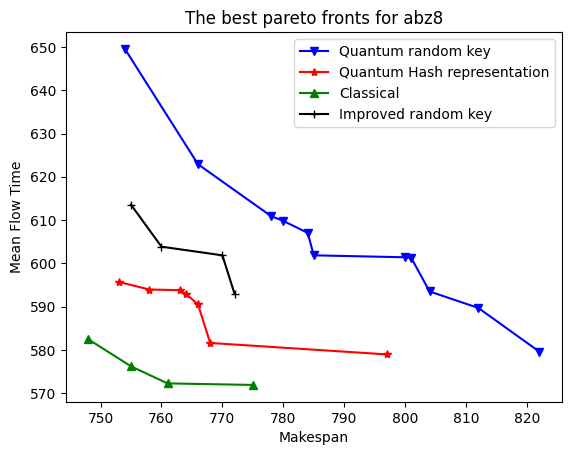

In [3]:
experiment_folders = ["Experiment_2_2025-02-19_23_23_50_random_key_main", "Experiment_2_2025-02-19_23_23_50_random_key_main", "Experiment_2_2025-02-19_23_23_50_random_key_main","Experiment_2_2025-02-19_23_23_50_random_key_main"]
subfolder_names = ["pareto_front_abz9_quantum_position_encoding_restricted_3", "pareto_front_abz9_quantum_position_encoding_restricted_2",  "pareto_front_abz9_quantum_position_encoding_restricted_8", "pareto_front_abz9_quantum_position_encoding_restricted_1"]

style_list = [("v", "b"), ("*", "r"), ("^", "green"), ("+", "black")]
algorithms = ["Quantum random key", "Quantum Hash representation", "Classical", "Improved random key"]
for i, experiment in enumerate(experiment_folders):
    cur_path = os.path.join(subfolder_names[i], "pareto_front.pkl")
    result_list = import_pareto_front(log_base, experiment, cur_path)
    plt.plot(result_list[0, :], result_list[1, :], marker=style_list[i][0], c=style_list[i][1], label=algorithms[i])

plt.title("The best pareto fronts for abz8")
plt.xlabel("Makespan")
plt.ylabel("Mean Flow Time")
plt.legend()
plt.show()

In [4]:
experiment_folders

['Experiment_2_2025-02-19_23_23_50_random_key_main',
 'Experiment_2_2025-02-19_23_23_50_random_key_main',
 'Experiment_2_2025-02-19_23_23_50_random_key_main',
 'Experiment_2_2025-02-19_23_23_50_random_key_main']

In [340]:
result_list

array([[755.  , 760.  , 770.  , 772.  ],
       [613.55, 603.85, 601.85, 592.95]])

Plotting Gantt chart

In [73]:
start_index = ord("A")
last_index = ord("Z")
alphabet_size = 26

def get_letter_code(index: int, alphabet_size: int, start_index: int) -> str:
    """This funciton is used to create the letter code for the job identifiers

    Parameters
    ----------
    index : int
        The corresponding integer value of the job identifier
    alphabet_size : int
        THe number of different letters in the alphabet
    start_index : int
        The offsett index for the char. For capital letters, this value should be 65 because ord('A') -> 65

    Returns
    -------
    str
        The letter code for the provided job number
    """
    res_list = []
    counter = 0
    while True:
        cur_position = alphabet_size**counter
        rest = index % alphabet_size**(counter+1)
        contribution = rest // cur_position
        if counter > 0:
            contribution -= 1
        res_list.append(contribution)
        if index // alphabet_size**(counter+1) == 0:
            break
        counter += 1

    res_list.reverse()
    letter_indexes = np.array(res_list) + start_index
    res_str = ""
    for letter in letter_indexes:
        res_str += chr(letter)
    
    return res_str

def get_operation_code_list(current_individual) -> list:
    str_operation_list = []
    job_counters = np.ones(shape=current_individual.n_jobs)
    for operation in current_individual.schedule.operation_list:
        # For each operation in the schedule -> find the operation code
        cur_job_number = operation.job
        # Get the number of times the job already has been processed
        cur_count = job_counters[cur_job_number]
        # Increment the job count for later iterations
        job_counters[cur_job_number] += 1
        letter_code = get_letter_code(cur_job_number, alphabet_size, start_index)
        str_operation_list.append(f"{letter_code}{int(cur_count)}")
    
    return str_operation_list

def plot_schedule_as_gantt(individual, box_height: float=0.4, plot_labels: bool=False, selected_cm: str="plt.cm.cividis", figsize=(10,5), problem_name: str="Unknown"):
    
    fig, ax = plt.subplots(figsize=figsize)

    machine_stop_times = np.zeros(shape=individual.n_machines)
    job_stop_times = np.zeros(shape=individual.n_jobs)
    
    str_operation_list = get_operation_code_list(individual)
    
    for o, cur_operation in enumerate(individual.schedule.operation_list):
        cur_machine = cur_operation.machine
        cur_job_number = cur_operation.job 
        # Create the collor for this job
        cur_color = list(eval(selected_cm)(cur_job_number/(individual.n_jobs-1)))
        cur_color[-1] = 0.6
        cur_color = tuple(cur_color)
        # Get the next start time
        cur_start_time = np.max([machine_stop_times[cur_machine], job_stop_times[cur_job_number]])
        # Create the rectangle for the operation
        rect = patches.Rectangle((cur_start_time, cur_machine - box_height + 1), cur_operation.duration, 2*box_height, linewidth=1, edgecolor="None", facecolor=cur_color, fill=True)
        # Add the operation label in the middle
        if plot_labels:
            ax.annotate(str_operation_list[o], (cur_start_time + cur_operation.duration/2, cur_machine+1), fontsize=10, ha='center', va='center', color="black")
        # update machine and job stop times
        machine_stop_times[cur_machine] = cur_start_time + cur_operation.duration
        job_stop_times[cur_job_number] = cur_start_time + cur_operation.duration
        ax.add_patch(rect)


    ax.set_ylim(0, individual.n_machines + 1)
    ax.set_xlim(0, individual.cur_fitness[0] + 40)
    ax.set_yticks(np.arange(1, individual.n_machines + 1))
    ax.vlines(individual.cur_fitness[0], 1, individual.n_machines, colors="r", lw=2.5)
    ax.text(individual.cur_fitness[0]-40, individual.n_machines + 0.5, f"Makespan: {int(individual.cur_fitness[0])}")
    plt.title(f"Gantt chart of schedule for the {'unknown'} problem instance")
    plt.xlabel("Time")
    plt.ylabel("Machine ID")
    plt.show()

Load the paretor front solutions

In [74]:
subfolder_name = "pareto_front_ft20_classical_0" #subfolder_names[0]
experiment_folder = "Experiment_2_2025-02-28_15_18_40_classical" #experiment_folders[0]
file_path = os.path.join(os.path.join(log_base, experiment_folder), os.path.join(subfolder_name, "pareto_front.pkl"))

with open(file_path, "rb") as read_pop_dump:
    cur_pop = pickle.load(read_pop_dump)

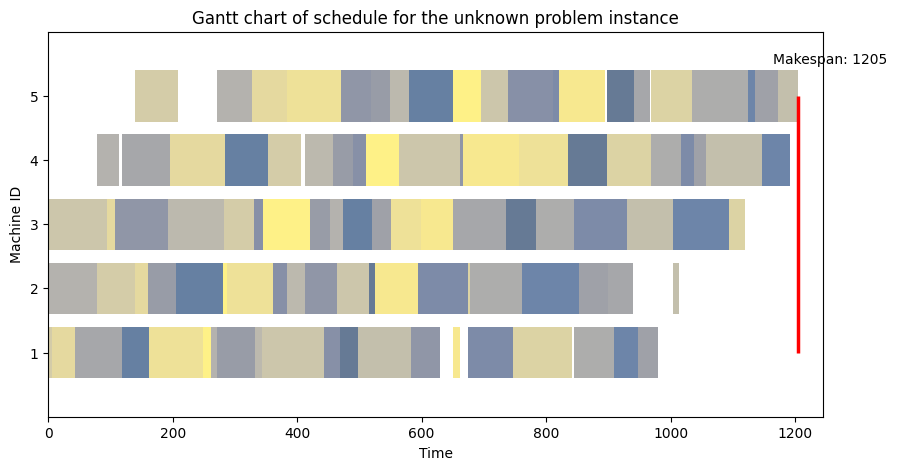

In [75]:
plot_schedule_as_gantt(cur_pop[6])

The operation list of the individual fromt he pareto front

In [8]:
cur_pop[6].schedule.operation_list

Producing operation code list for verifying the results on https://www.jobshoppuzzle.com/benchmarks.html

In [9]:
str(get_operation_code_list(cur_pop[6])).replace("[", "").replace("]", "").replace("'", "").replace(" ", "")

'K1,O1,N1,Q1,I1,O2,Q2,K2,F1,B1,Q3,G1,R1,I2,L1,O3,B2,T1,K3,T2,Q4,R2,G2,O4,K4,L2,E1,B3,E2,T3,N2,Q5,L3,O5,F2,G3,L4,N3,E3,R3,K5,G4,A1,F3,B4,E4,A2,S1,G5,H1,T4,M1,L5,D1,R4,B5,F4,N4,S2,S3,F5,P1,T5,I3,J1,N5,D2,S4,E5,A3,C1,D3,R5,P2,J2,J3,H2,S5,A4,D4,I4,C2,A5,P3,I5,H3,J4,M2,M3,P4,D5,H4,C3,J5,P5,C4,M4,H5,C5,M5'

In [346]:
subfolder_name = "pareto_front_ft06_classical_3" #subfolder_names[0]
experiment_folder = "Experiment_2_2025-02-28_15_18_40_classical" #experiment_folders[0]
file_path = os.path.join(os.path.join(log_base, experiment_folder), os.path.join(subfolder_name, "pareto_front.pkl"))

with open(file_path, "rb") as read_pop_dump:
    cur_pop = pickle.load(read_pop_dump)

In [347]:
math.factorial(36)//(math.factorial(6)**6)

2670177736637149247308800

In [348]:
str(get_operation_code_list(cur_pop[4])).replace("[", "").replace("]", "").replace("'", "").replace(" ", "")

'E1,F1,F2,B1,A1,A2,E2,F3,C1,E3,A3,C2,B2,E4,D1,F4,A4,D2,B3,C3,E5,A5,E6,F5,D3,F6,D4,A6,C4,C5,B4,D5,B5,C6,D6,B6'

# Calculating the hypervolume

The hypervolume of the final pareto optimal front is calculated for each result in the log data

In [10]:
test_points = np.array([[1,3],[2,2],[3,1]])
reference_point = np.array([[5,5]])
n_points = test_points.shape[0]

In [11]:
def calc_hypervolume(front_points: np.ndarray, reference_point: np.ndarray):
    total_volume = 0
    n_points = front_points.shape[0]
    for point in range(n_points):
        if point < n_points-1:
            cur_width = np.abs(front_points[point+1][0] - front_points[point][0])
        else:
            cur_width = np.abs(reference_point[0] - front_points[point][0])

        cur_height = np.abs(reference_point[1] - front_points[point][1])

        total_volume += cur_height * cur_width

    return total_volume

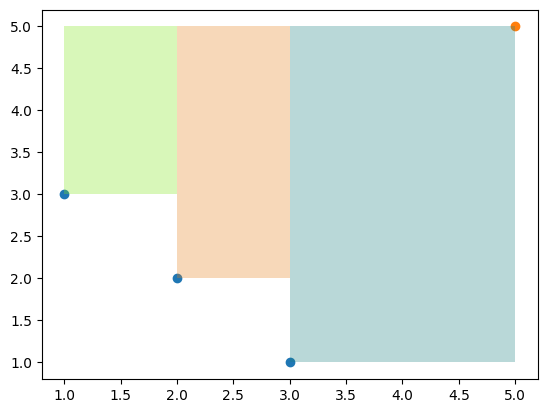

In [12]:
fig, ax = plt.subplots()
plt.scatter(test_points[:, 0], test_points[:, 1])
plt.scatter(reference_point[0][0], reference_point[0][1])

rect_1 = patches.Rectangle((1, 3), 1, 2, linewidth=1, edgecolor="None", facecolor=(0.5, 0.9, 0.1, 0.3), fill=True)
ax.add_patch(rect_1)

rect_1 = patches.Rectangle((2, 2), 1, 3, linewidth=1, edgecolor="None", facecolor=(0.9, 0.5, 0.1, 0.3), fill=True)
ax.add_patch(rect_1)

rect_1 = patches.Rectangle((3, 1), 2, 4, linewidth=1, edgecolor="None", facecolor=(0.1, 0.5, 0.5, 0.3), fill=True)
ax.add_patch(rect_1)

In [13]:
n_repetitions = 10
experiment_folders = [
                        ["Experiment_2_2025-02-28_15_18_40_classical",
                        "Experiment_2_2025-02-19_23_23_50_random_key_main",
                        "Experiment_2_2025-02-20_22_19_28_hash_base",
                        "Experiment_2_2025-02-24_09_40_06_improved_random_key"],
                        ["Experiment_2_2025-02-28_15_18_40_classical_2",
                        "Experiment_2_2025-02-26_08_05_08_random_key_main_2",
                        "Experiment_2_2025-02-26_08_05_08_hash_base_2",
                        "Experiment_2_2025-02-25_10_04_37_improved_random_key_2"]
                    ]

method_names = [["classical", "quantum_position_encoding_restricted", "quantum_hash_base_encoding", "qmea_enhanced_random_key"], ["classical", "quantum_position_encoding_restricted", "quantum_hash_base_encoding", "qmea_enhanced_random_key"]]
problem_names = [["ft06", "ft10", "ft20", "abz7", "abz8", "abz9", "la28", "la40"], ["la21", "la22", "la23", "la24", "la25", "la26", "la27", "la29"]]
front_dataset = {"Problem" : [], "Method" : [], "Repetition" : [], "Makespan" : [], "Mean Flow Time" : []}
for block in range(len(problem_names)):
    for problem_name in problem_names[block]:
        for i, method_name in enumerate(method_names[block]):
            for repetition in range(n_repetitions):
                # Create the path to the front file
                file_path = os.path.join(os.path.join(log_base, experiment_folders[block][i]), os.path.join(f"pareto_front_{problem_name}_{method_name}_{repetition}", "pareto_front.pkl"))
                # Import the population object
                with open(file_path, "rb") as read_pop_dump:
                    cur_front = pickle.load(read_pop_dump)

                for indiv in cur_front:
                    front_dataset["Problem"].append(problem_name)
                    front_dataset["Method"].append(method_name)
                    front_dataset["Repetition"].append(repetition)
                    front_dataset["Makespan"].append(indiv.cur_fitness[0])
                    front_dataset["Mean Flow Time"].append(indiv.cur_fitness[1])

            
front_dataset = pd.DataFrame(front_dataset)
front_dataset.drop_duplicates(inplace=True)
min_columns = front_dataset.groupby(["Problem"])[["Makespan", "Mean Flow Time"]].transform(lambda x: x.min()).rename(columns={"Makespan" : "min makespan", "Mean Flow Time" : "min mean flow time"})
max_columns = front_dataset.groupby(["Problem"])[["Makespan", "Mean Flow Time"]].transform(lambda x: x.max()).rename(columns={"Makespan" : "max makespan", "Mean Flow Time" : "max mean flow time"})
front_dataset = pd.concat([front_dataset, min_columns, max_columns], axis=1)
front_dataset

,Problem,Method,Repetition,Makespan,Mean Flow Time,min makespan,min mean flow time,max makespan,max mean flow time
0,ft06,classical,0,58.0,39.666667,57.0,39.666667,58.0,42.50
1,ft06,classical,0,57.0,42.500000,57.0,39.666667,58.0,42.50
83,ft06,classical,1,58.0,39.666667,57.0,39.666667,58.0,42.50
84,ft06,classical,1,57.0,42.500000,57.0,39.666667,58.0,42.50
170,ft06,classical,2,58.0,39.666667,57.0,39.666667,58.0,42.50
...,...,...,...,...,...,...,...,...,...
14444,la29,qmea_enhanced_random_key,9,1238.0,995.800000,1210.0,920.550000,1611.0,1080.75
14445,la29,qmea_enhanced_random_key,9,1300.0,955.400000,1210.0,920.550000,1611.0,1080.75
14446,la29,qmea_enhanced_random_key,9,1265.0,960.250000,1210.0,920.550000,1611.0,1080.75
14447,la29,qmea_enhanced_random_key,9,1255.0,984.650000,1210.0,920.550000,1611.0,1080.75


Normalization of makespan and mean flow time with min/max scaling

In [14]:
def min_max_scaling(x):
    cur_makespan = (x["Makespan"] - x["min makespan"])/(x["max makespan"] - x["min makespan"])
    cur_mean_flow_time = (x["Mean Flow Time"] - x["min mean flow time"])/(x["max mean flow time"] - x["min mean flow time"])
    new_columns = pd.concat([x, cur_makespan, cur_mean_flow_time], axis=1).reset_index(drop=True)
    return new_columns

norm_df = front_dataset.groupby(["Problem"]).apply(min_max_scaling, include_groups=False).reset_index().rename(columns={0 : "Makespan norm", 1 : "Mean Flow Time norm"})
norm_df

,Problem,level_1,Method,Repetition,Makespan,Mean Flow Time,min makespan,min mean flow time,max makespan,max mean flow time,Makespan norm,Mean Flow Time norm
0,abz7,0,classical,0,751.0,593.000000,694.0,574.500000,805.0,640.45,0.513514,0.280516
1,abz7,1,classical,0,702.0,614.100000,694.0,574.500000,805.0,640.45,0.072072,0.600455
2,abz7,2,classical,0,735.0,593.100000,694.0,574.500000,805.0,640.45,0.369369,0.282032
3,abz7,3,classical,0,712.0,605.550000,694.0,574.500000,805.0,640.45,0.162162,0.470811
4,abz7,4,classical,0,721.0,600.600000,694.0,574.500000,805.0,640.45,0.243243,0.395754
...,...,...,...,...,...,...,...,...,...,...,...,...
3781,la40,181,qmea_enhanced_random_key,9,1291.0,1100.533333,1275.0,1044.066667,1528.0,1181.80,0.063241,0.409971
3782,la40,182,qmea_enhanced_random_key,9,1354.0,1091.333333,1275.0,1044.066667,1528.0,1181.80,0.312253,0.343175
3783,la40,183,qmea_enhanced_random_key,9,1332.0,1099.466667,1275.0,1044.066667,1528.0,1181.80,0.225296,0.402227
3784,la40,184,qmea_enhanced_random_key,9,1341.0,1095.066667,1275.0,1044.066667,1528.0,1181.80,0.260870,0.370281


Find the Nadir point for both the normalized solutions and the raw points. Note that it is defined as the maximum in both dimensions 

In [15]:
w_reference_point = front_dataset.groupby(["Problem"])[["Makespan", "Mean Flow Time"]].transform(lambda x: x.max()).rename(columns={"Makespan" : "Reference_1", "Mean Flow Time" : "Reference_2"})
w_reference_point_norm = norm_df.groupby(["Problem"])[["Makespan norm", "Mean Flow Time norm"]].transform(lambda x: x.max()).rename(columns={"Makespan norm" : "Reference_1", "Mean Flow Time norm" : "Reference_2"})

Add the reference points to the dataset

In [16]:
hypervol_ready = pd.concat([front_dataset, w_reference_point], axis=1)
hypervol_ready_norm = pd.concat([norm_df, w_reference_point_norm], axis=1)

In [17]:
hypervol_ready[(hypervol_ready["Problem"] == "abz7") & (hypervol_ready["Method"] == "classical") & (hypervol_ready["Repetition"] == 0)][["Makespan", "Mean Flow Time"]]

,Makespan,Mean Flow Time
3103,751.0,593.00
3104,702.0,614.10
3106,735.0,593.10
3107,712.0,605.55
3108,721.0,600.60
3111,706.0,607.35
3112,705.0,609.90
3113,725.0,598.80
3114,729.0,594.50
3116,727.0,596.20


In [18]:
hypervol_ready[(hypervol_ready["Problem"] == "abz7") & (hypervol_ready["Method"] == "classical") & (hypervol_ready["Repetition"] == 0)][["Makespan", "Mean Flow Time"]].sort_values(by="Makespan")

,Makespan,Mean Flow Time
3104,702.0,614.10
3112,705.0,609.90
3111,706.0,607.35
3107,712.0,605.55
3108,721.0,600.60
3113,725.0,598.80
3116,727.0,596.20
3114,729.0,594.50
3106,735.0,593.10
3103,751.0,593.00


Calculate the Hypervolume and find the agregate over the repetitions

Find the best fronts according to hypervolume for each algorithm for each test problem accross the runs:

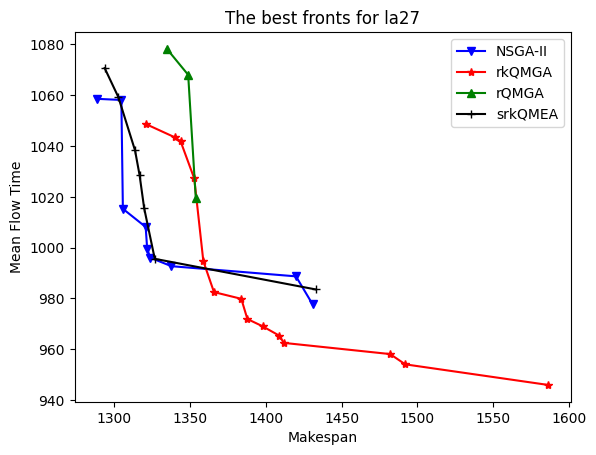

In [68]:
experiment_folders = ["Experiment_2_2025-02-28_15_18_40_classical_2",
                        "Experiment_2_2025-02-26_08_05_08_random_key_main_2",
                        "Experiment_2_2025-02-26_08_05_08_hash_base_2",
                        "Experiment_2_2025-02-25_10_04_37_improved_random_key_2"]
experiment_folders_2 = ["Experiment_2_2025-02-28_15_18_40_classical",
                        "Experiment_2_2025-02-19_23_23_50_random_key_main",
                        "Experiment_2_2025-02-20_22_19_28_hash_base",
                        "Experiment_2_2025-02-24_09_40_06_improved_random_key"]

cur_front_plot = hypervol_ready_norm.groupby(["Problem", "Method", "Repetition"]).apply(lambda x: calc_hypervolume(x[["Makespan norm", "Mean Flow Time norm"]].sort_values(by="Makespan norm").to_numpy(), x[["Reference_1", "Reference_2"]].to_numpy()[0,:]), include_groups=False).reset_index()
cur_front_plot.rename(columns={0 : "Hypervolume"}, inplace=True)
cur_front_plot = cur_front_plot[cur_front_plot["Hypervolume"] == cur_front_plot.groupby(["Problem", "Method"])[["Hypervolume"]].transform("max")["Hypervolume"]]

selected_problem = "la27"
classical_rep = cur_front_plot[(cur_front_plot["Problem"] == selected_problem) & (cur_front_plot["Method"] == "classical")]["Repetition"].iloc[0]
rk_rep = cur_front_plot[(cur_front_plot["Problem"] == selected_problem) & (cur_front_plot["Method"] == "quantum_position_encoding_restricted")]["Repetition"].iloc[0]
r_rep = cur_front_plot[(cur_front_plot["Problem"] == selected_problem) & (cur_front_plot["Method"] == "quantum_hash_base_encoding")]["Repetition"].iloc[0]
srk_rep = cur_front_plot[(cur_front_plot["Problem"] == selected_problem) & (cur_front_plot["Method"] == "qmea_enhanced_random_key")]["Repetition"].iloc[0]

subfolder_names = [f"pareto_front_{selected_problem}_classical_{classical_rep}",
                   f"pareto_front_{selected_problem}_quantum_position_encoding_restricted_{rk_rep}",
                   f"pareto_front_{selected_problem}_quantum_hash_base_encoding_{r_rep}",
                   f"pareto_front_{selected_problem}_qmea_enhanced_random_key_{srk_rep}"
                ]

style_list = [("v", "b"), ("*", "r"), ("^", "green"), ("+", "black")]
algorithms = ["NSGA-II", "rkQMGA", "rQMGA", "srkQMEA"]
for i, experiment in enumerate(experiment_folders):#enumerate(experiment_folders[:3]):
    cur_path = os.path.join(subfolder_names[i], "pareto_front.pkl")
    result_list = import_pareto_front(log_base, experiment, cur_path)
    plt.plot(result_list[0, :], result_list[1, :], marker=style_list[i][0], c=style_list[i][1], label=algorithms[i])

plt.title(f"The best fronts for {selected_problem}")
plt.xlabel("Makespan")
plt.ylabel("Mean Flow Time")
plt.legend()
plt.show()

In [78]:
subfolder_name = subfolder_names[1]
experiment_folder = experiment_folders[1]
file_path = os.path.join(os.path.join(log_base, experiment_folder), os.path.join(subfolder_name, "pareto_front.pkl"))

with open(file_path, "rb") as read_pop_dump:
    cur_pop = pickle.load(read_pop_dump)

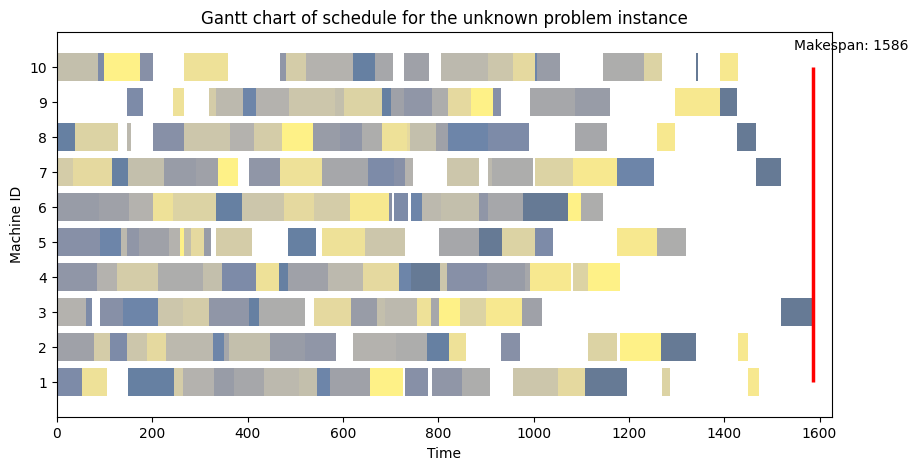

In [79]:
plot_schedule_as_gantt(cur_pop[0])

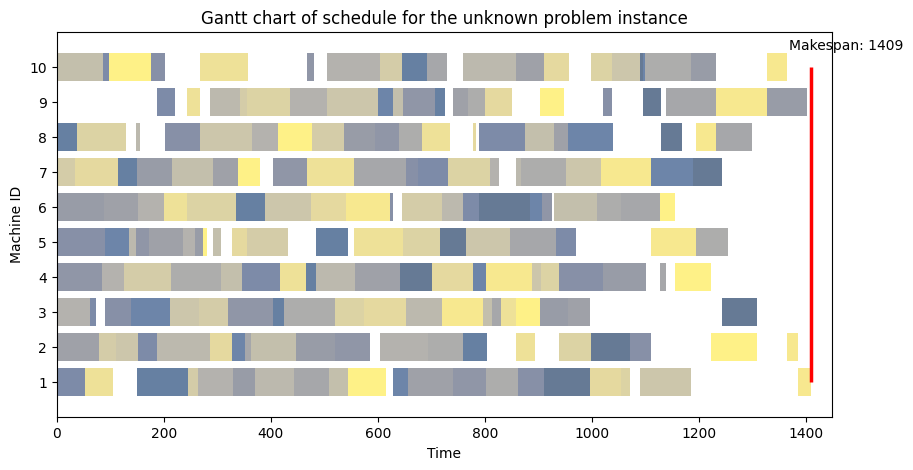

In [80]:
plot_schedule_as_gantt(cur_pop[-1])

Prepare reference points further

In [20]:
reference_points = hypervol_ready.groupby(["Problem", "Method"])[["Reference_1", "Reference_2"]].agg("max")
reference_points["Reference Point"] = list(zip(reference_points["Reference_1"], reference_points["Reference_2"]))
reference_points.rename(index={"classical": "NSGA-II", "qmea_enhanced_random_key" : "srkQMGA", "quantum_hash_base_encoding" : "rQMGA", "quantum_position_encoding_restricted":"rkQMGA"}, inplace=True)
reference_points

reference_points_norm = hypervol_ready_norm.groupby(["Problem", "Method"])[["Reference_1", "Reference_2"]].agg("max")
reference_points_norm["Reference Point"] = list(zip(reference_points_norm["Reference_1"], reference_points_norm["Reference_2"]))
reference_points_norm.rename(index={"classical": "NSGA-II", "qmea_enhanced_random_key" : "srkQMGA", "quantum_hash_base_encoding" : "rQMGA", "quantum_position_encoding_restricted":"rkQMGA"}, inplace=True)
reference_points_norm

Reference_1  Reference_2 Reference Point
Problem Method                                           
abz7    NSGA-II          1.0          1.0      (1.0, 1.0)
        srkQMGA          1.0          1.0      (1.0, 1.0)
        rQMGA            1.0          1.0      (1.0, 1.0)
        rkQMGA           1.0          1.0      (1.0, 1.0)
abz8    NSGA-II          1.0          1.0      (1.0, 1.0)
...                      ...          ...             ...
la29    rkQMGA           1.0          1.0      (1.0, 1.0)
la40    NSGA-II          1.0          1.0      (1.0, 1.0)
        srkQMGA          1.0          1.0      (1.0, 1.0)
        rQMGA            1.0          1.0      (1.0, 1.0)
        rkQMGA           1.0          1.0      (1.0, 1.0)

[64 rows x 3 columns]

In [21]:
reference_points

Reference_1  Reference_2    Reference Point
Problem Method                                              
abz7    NSGA-II        805.0       640.45    (805.0, 640.45)
        srkQMGA        805.0       640.45    (805.0, 640.45)
        rQMGA          805.0       640.45    (805.0, 640.45)
        rkQMGA         805.0       640.45    (805.0, 640.45)
abz8    NSGA-II        821.0       660.20     (821.0, 660.2)
...                      ...          ...                ...
la29    rkQMGA        1611.0      1080.75  (1611.0, 1080.75)
la40    NSGA-II       1528.0      1181.80   (1528.0, 1181.8)
        srkQMGA       1528.0      1181.80   (1528.0, 1181.8)
        rQMGA         1528.0      1181.80   (1528.0, 1181.8)
        rkQMGA        1528.0      1181.80   (1528.0, 1181.8)

[64 rows x 3 columns]

In [103]:
#hypervol_ready["Reference Point"] = list(zip(w_reference_point["Reference_1"], w_reference_point["Reference_2"]))
#hypervol_ready_norm["Reference Point"] = list(zip(w_reference_point_norm["Reference_1"], w_reference_point_norm["Reference_2"]))

hypervolume_res = hypervol_ready.groupby(["Problem", "Method", "Repetition"]).apply(lambda x: calc_hypervolume(x[["Makespan", "Mean Flow Time"]].sort_values(by="Makespan").to_numpy(), x[["Reference_1", "Reference_2"]].to_numpy()[0,:]), include_groups=False) 
hypervolume_res = hypervolume_res.groupby(["Problem", "Method"]).agg(["mean", "min", "max", "std"]).reset_index()
hypervolume_res_norm_2 = hypervol_ready_norm.groupby(["Problem", "Method", "Repetition"]).apply(lambda x: calc_hypervolume(x[["Makespan norm", "Mean Flow Time norm"]].sort_values(by="Makespan norm").to_numpy(), x[["Reference_1", "Reference_2"]].to_numpy()[0,:]), include_groups=False) 
hypervolume_res_norm = hypervolume_res_norm_2.groupby(["Problem", "Method"]).agg(["mean", "min", "max", "std"]).reset_index()

hypervolume_res = hypervolume_res.rename(columns={"Method" : "Candidate", "mean" : "Mean Hypervolume", "min" : "Min Hypervolume", "max" : "Max Hypervolume", "std" : "Std Hypervolume"})
hypervolume_res_norm = hypervolume_res_norm.rename(columns={"Method" : "Candidate", "mean" : "Mean Hypervolume", "min" : "Min Hypervolume", "max" : "Max Hypervolume", "std" : "Std Hypervolume"})

hypervolume_res.set_index(["Problem", "Candidate"], inplace=True)
hypervolume_res_norm.set_index(["Problem", "Candidate"], inplace=True)

hypervolume_res.rename(index={"classical": "NSGA-II", "qmea_enhanced_random_key" : "srkQMGA", "quantum_hash_base_encoding" : "rQMGA", "quantum_position_encoding_restricted":"rkQMGA"}, inplace=True)
hypervolume_res_norm.rename(index={"classical": "NSGA-II", "qmea_enhanced_random_key" : "srkQMGA", "quantum_hash_base_encoding" : "rQMGA", "quantum_position_encoding_restricted":"rkQMGA"}, inplace=True)

In [39]:
#hypervolume_res_norm = hypervolume_res_norm[hypervolume_res_norm.index.get_level_values(1) != "srkQMGA"]

In [81]:
hypervolume_res_norm

Mean Hypervolume  Min Hypervolume  Max Hypervolume  \
Problem Candidate                                                       
abz7    NSGA-II            0.650786         0.455389         0.962304   
        srkQMGA            0.452786         0.315951         0.552780   
        rQMGA              0.448513         0.339200         0.629053   
        rkQMGA             0.514093         0.385284         0.633253   
abz8    NSGA-II            0.569036         0.363462         0.743853   
...                             ...              ...              ...   
la29    rkQMGA             0.765216         0.578191         0.910635   
la40    NSGA-II            0.660895         0.568906         0.978374   
        srkQMGA            0.573180         0.529269         0.672233   
        rQMGA              0.513819         0.430388         0.586958   
        rkQMGA             0.576300         0.510427         0.667347   

                   Std Hypervolume  
Problem Candidate                   
abz7    NSGA-II           0.152754  
        srkQMGA           0.066202  
        rQMGA             0.084871  
        rkQMGA            0.067837  
abz8    NSGA-II           0.117213  
...                            ...  
la29    rkQMGA            0.100415  
la40    NSGA-II           0.119219  
        srkQMGA           0.044629  
        rQMGA             0.049682  
        rkQMGA            0.051909  

[64 rows x 4 columns]

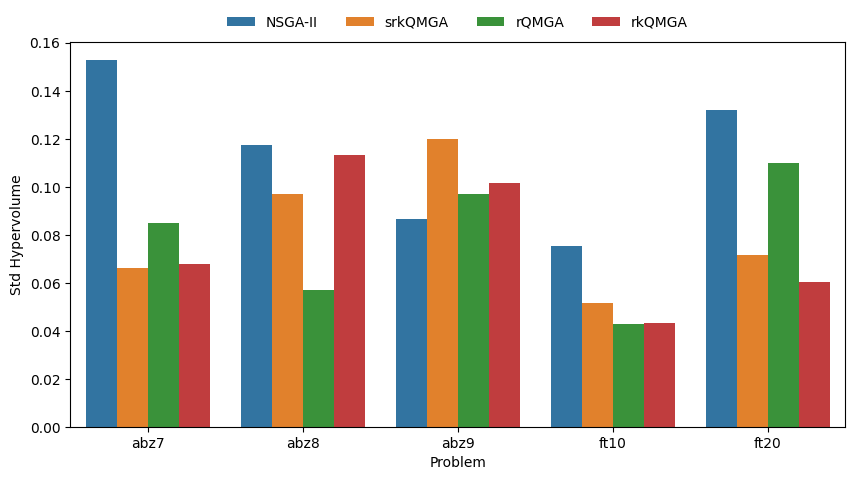

In [82]:
fig, ax = plt.subplots(figsize=(10, 5))
#ax.set_title("Max Hypervolume for benchmarks ft06-ft20 and abz7-abz9")
sns.barplot(data=hypervolume_res_norm.reset_index()[hypervolume_res_norm.reset_index()["Problem"].isin(["abz7", "abz8", "abz9", "ft10", "ft20"])], x="Problem", y="Std Hypervolume", hue="Candidate", ax=ax)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=4, title=None, frameon=False,
)

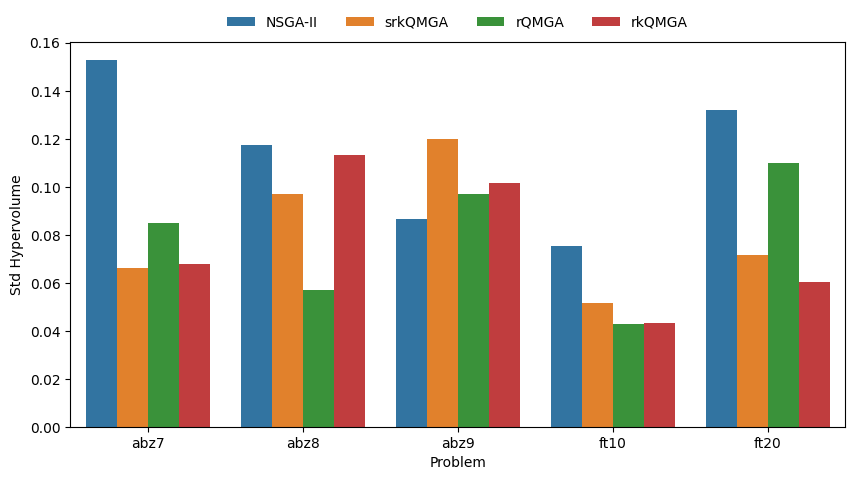

In [83]:
fig, ax = plt.subplots(figsize=(10, 5))
#ax.set_title("Max Hypervolume for benchmarks ft06-ft20 and abz7-abz9")
sns.barplot(data=hypervolume_res_norm.reset_index()[hypervolume_res_norm.reset_index()["Problem"].isin(["abz7", "abz8", "abz9", "ft10", "ft20"])], x="Problem", y="Std Hypervolume", hue="Candidate", ax=ax)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=4, title=None, frameon=False,
)

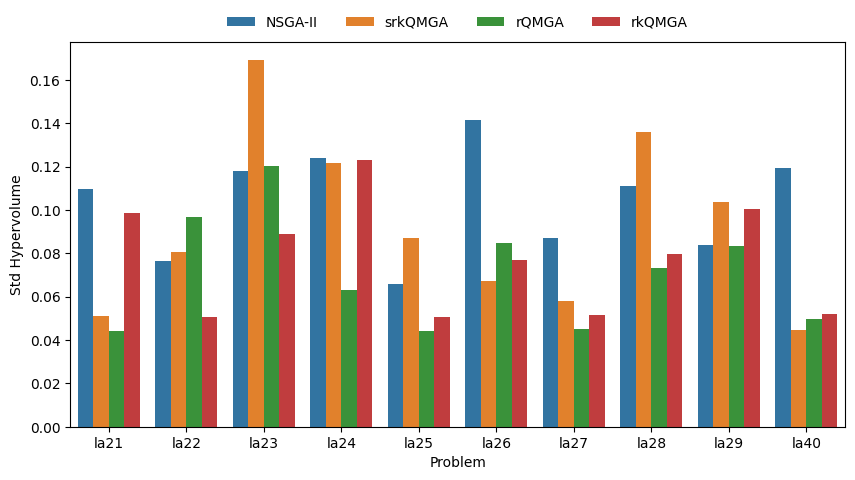

In [84]:
fig, ax = plt.subplots(figsize=(10, 5))
#ax.set_title("Max Hypervolume for benchmarks la21-la29 and la40")
sns.barplot(data=hypervolume_res_norm.reset_index()[hypervolume_res_norm.reset_index()["Problem"].isin(["la21", "la22", "la23", "la24", "la25", "la26", "la27", "la28", "la29","la40"])], x="Problem", y="Std Hypervolume", hue="Candidate", ax=ax)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=4, title=None, frameon=False,
)

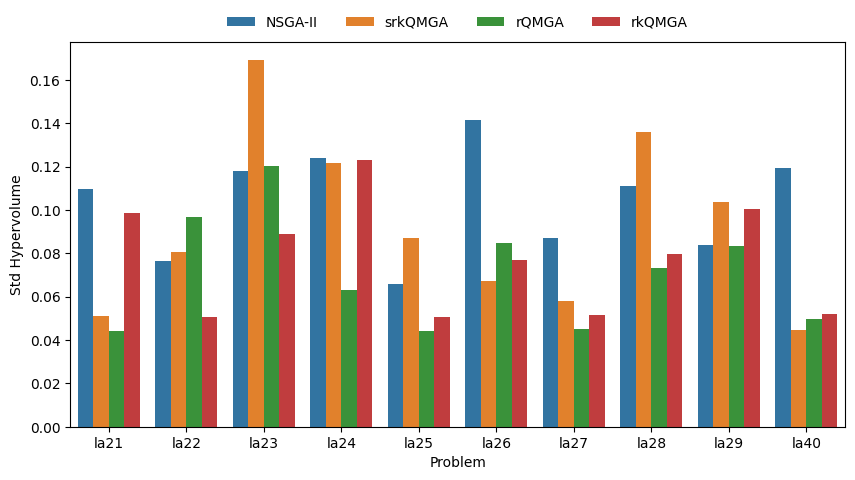

In [85]:
fig, ax = plt.subplots(figsize=(10, 5))
#ax.set_title("Max Hypervolume for benchmarks la21-la29 and la40")
sns.barplot(data=hypervolume_res_norm.reset_index()[hypervolume_res_norm.reset_index()["Problem"].isin(["la21", "la22", "la23", "la24", "la25", "la26", "la27", "la28", "la29", "la40"])], x="Problem", y="Std Hypervolume", hue="Candidate", ax=ax)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=4, title=None, frameon=False,
)

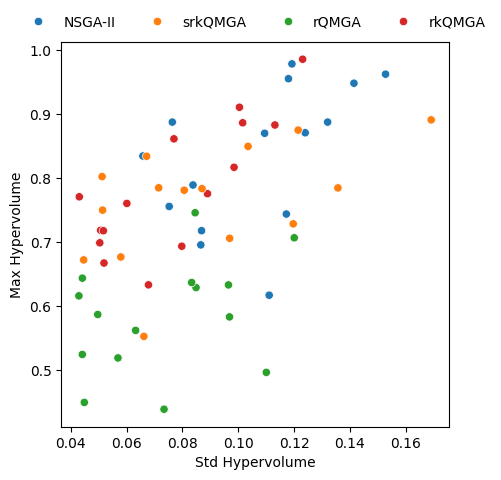

In [95]:
cur_data = hypervolume_res_norm.reset_index()[hypervolume_res_norm.reset_index()["Problem"].isin(["abz7", "abz8", "abz9", "ft10", "ft20","la21", "la22", "la23", "la24", "la25", "la26", "la27", "la28", "la29","la40"])]

fig, ax = plt.subplots(figsize=(5, 5))

sns.scatterplot(data=cur_data, x="Std Hypervolume", y="Max Hypervolume", hue="Candidate")
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=4, title=None, frameon=False,
)

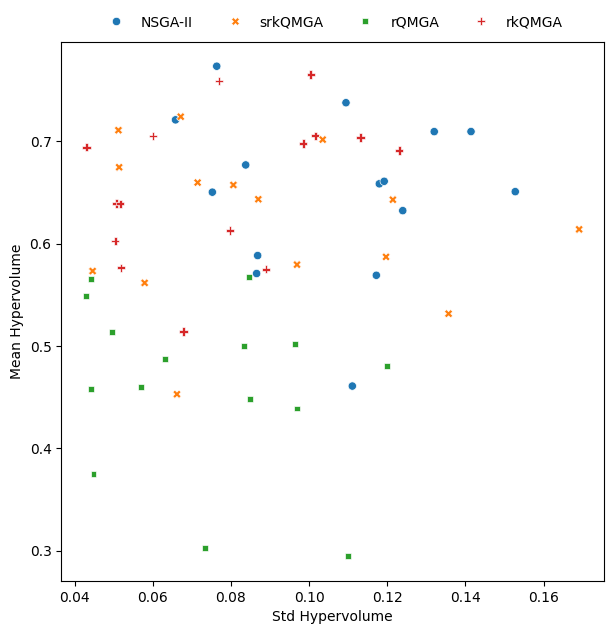

In [101]:
fig, ax = plt.subplots(figsize=(7, 7))

sns.scatterplot(data=cur_data, x="Std Hypervolume", y="Mean Hypervolume", style="Candidate", hue="Candidate")
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=4, title=None, frameon=False,
)

Box plot of the hypervolume

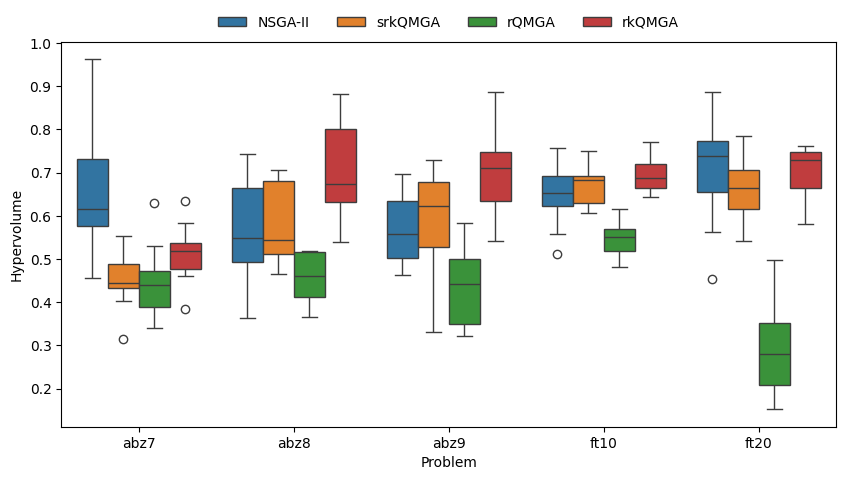

In [119]:
cur_data = hypervolume_res_norm_2.reset_index()[hypervolume_res_norm_2.reset_index()["Problem"].isin(["abz7", "abz8", "abz9", "ft10", "ft20"])] # "la21", "la22", "la23", "la24", "la25", "la26", "la27", "la28", "la29","la40"
cur_data.rename(columns={0 : "Hypervolume", "Method" : "Candidate"}, inplace=True)
cur_data.replace({"Candidate" : {"classical": "NSGA-II", 
                                   "qmea_enhanced_random_key" : "srkQMGA", 
                                   "quantum_hash_base_encoding" : "rQMGA", 
                                   "quantum_position_encoding_restricted":"rkQMGA"
                                }}, inplace=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=cur_data, x="Problem", y="Hypervolume", hue="Candidate")
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=4, title=None, frameon=False,
)

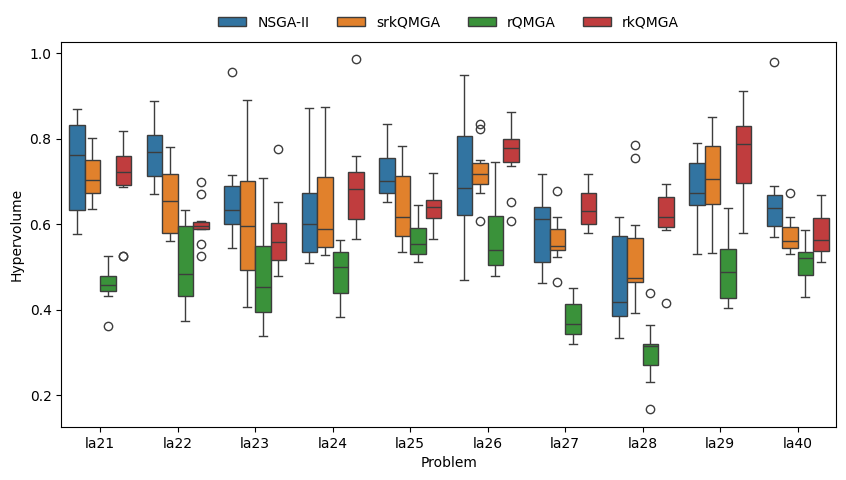

In [120]:
cur_data = hypervolume_res_norm_2.reset_index()[hypervolume_res_norm_2.reset_index()["Problem"].isin(["la21", "la22", "la23", "la24", "la25", "la26", "la27", "la28", "la29","la40"])]
cur_data.rename(columns={0 : "Hypervolume", "Method" : "Candidate"}, inplace=True)
cur_data.replace({"Candidate" : {"classical": "NSGA-II", 
                                   "qmea_enhanced_random_key" : "srkQMGA", 
                                   "quantum_hash_base_encoding" : "rQMGA", 
                                   "quantum_position_encoding_restricted":"rkQMGA"
                                }}, inplace=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=cur_data, x="Problem", y="Hypervolume", hue="Candidate")
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=4, title=None, frameon=False,
)

In [28]:
log_base = "..\\logdata_2\\"
log_folders = [
    "Experiment_2_2025-02-28_15_18_40_classical",
    "Experiment_2_2025-02-28_15_18_40_classical_2",
    "Experiment_2_2025-02-19_23_23_50_random_key_main",
    "Experiment_2_2025-02-26_08_05_08_random_key_main_2",
    "Experiment_2_2025-02-20_22_19_28_hash_base",
    "Experiment_2_2025-02-26_08_05_08_hash_base_2",
    "Experiment_2_2025-02-24_09_40_06_improved_random_key",
    "Experiment_2_2025-02-25_10_04_37_improved_random_key_2",
]

reduced_agg_columns = ["Min Makespan", "Min Mean Flow Time", "Spread", "N Non-dominated solutions"]
concat_dfs = []
for log_folder in log_folders:
    # For each log folder, create the full path
    cur_log_path = os.path.join(log_base, log_folder)
    for cur_file in os.listdir(cur_log_path):
        # For each item in the log folder, find the csv file in the root
        if cur_file[-4:] == ".csv":
            # Create the path to the csv file
            cur_csv_file_path = os.path.join(cur_log_path, cur_file)
            # Read the csv file from disc
            result_df = pd.read_csv(cur_csv_file_path, index_col=False)
            # Remove data from all iterations except the last one
            result_df = result_df[result_df["Iteration"] == result_df["Iteration"].max()].reset_index(drop=True)
            # Aggregate over the repetitions
            result_df = result_df.groupby(["Problem", "Candidate"]).agg({col_name : ["min", "mean", "std", "count"] for col_name in reduced_agg_columns})
            concat_dfs.append(result_df)

convergence_df = pd.concat(concat_dfs, axis=0)
convergence_df.rename(index={"classical": "NSGA-II", "qmea_enhanced_random_key" : "srkQMGA", "quantum_hash_base_encoding" : "rQMGA", "quantum_position_encoding_restricted":"rkQMGA"}, inplace=True)
convergence_df

Min Makespan                          Min Mean Flow Time  \
                           min    mean        std count                min   
Problem Candidate                                                            
abz7    NSGA-II          694.0   704.8   9.186947    10         574.500000   
abz8    NSGA-II          713.0   729.5   8.343327    10         596.350000   
abz9    NSGA-II          737.0   757.9   9.643075    10         585.450000   
ft06    NSGA-II           57.0    57.0   0.000000    10          39.666667   
ft10    NSGA-II          968.0   992.6  17.218853    10         644.800000   
...                        ...     ...        ...   ...                ...   
la24    srkQMGA          988.0   998.7   6.684144    10         784.600000   
la25    srkQMGA         1034.0  1050.2  11.272385    10         797.133333   
la26    srkQMGA         1229.0  1249.9   9.993887    10         942.900000   
la27    srkQMGA         1294.0  1315.3  12.184234    10         983.550000   
la29    srkQMGA         1234.0  1251.2  10.706177    10         920.550000   

                                                   Spread                      \
                          mean        std count       min      mean       std   
Problem Candidate                                                               
abz7    NSGA-II     591.570000   8.084010    10  0.951989  0.977041  0.014080   
abz8    NSGA-II     607.905000   6.816502    10  0.932374  0.971278  0.018843   
abz9    NSGA-II     593.615000   8.328133    10  0.882850       inf       NaN   
ft06    NSGA-II      39.666667   0.000000    10  0.969855  0.969855  0.000000   
ft10    NSGA-II     681.350000  16.353474    10  0.890523  0.961395  0.027389   
...                        ...        ...   ...       ...       ...       ...   
la24    srkQMGA     813.933333  14.693175    10  0.902507  0.970718  0.028472   
la25    srkQMGA     814.533333  10.977913    10  0.902831  0.947873  0.028198   
la26    srkQMGA     961.795000  12.271680    10  0.933619  0.950991  0.012514   
la27    srkQMGA    1000.165000  10.164728    10  0.918586  0.951743  0.014831   
la29    srkQMGA     945.590000  17.843530    10  0.881324  0.933714  0.037095   

                        N Non-dominated solutions                       
                  count                       min mean       std count  
Problem Candidate                                                       
abz7    NSGA-II      10                         2  5.6  2.366432    10  
abz8    NSGA-II      10                         3  6.7  2.668749    10  
abz9    NSGA-II      10                         1  6.6  4.273952    10  
ft06    NSGA-II      10                         2  2.0  0.000000    10  
ft10    NSGA-II      10                         3  4.7  1.418136    10  
...                 ...                       ...  ...       ...   ...  
la24    srkQMGA      10                         2  4.9  2.685351    10  
la25    srkQMGA      10                         4  7.4  2.547330    10  
la26    srkQMGA      10                         4  7.4  2.319004    10  
la27    srkQMGA      10                         4  8.4  2.503331    10  
la29    srkQMGA      10                         5  7.7  2.213594    10  

[64 rows x 16 columns]

In [29]:
hypervolume_res.columns

Index(['Mean Hypervolume', 'Min Hypervolume', 'Max Hypervolume',
       'Std Hypervolume'],
      dtype='object')

In [30]:
reference_points["Reference Point"]

Problem  Method 
abz7     NSGA-II      (805.0, 640.45)
         srkQMGA      (805.0, 640.45)
         rQMGA        (805.0, 640.45)
         rkQMGA       (805.0, 640.45)
abz8     NSGA-II       (821.0, 660.2)
                          ...        
la29     rkQMGA     (1611.0, 1080.75)
la40     NSGA-II     (1528.0, 1181.8)
         srkQMGA     (1528.0, 1181.8)
         rQMGA       (1528.0, 1181.8)
         rkQMGA      (1528.0, 1181.8)
Name: Reference Point, Length: 64, dtype: object

In [31]:
pd.concat([convergence_df, hypervolume_res, reference_points["Reference Point"]], axis=1)

,,"(Min Makespan, min)","(Min Makespan, mean)","(Min Makespan, std)","(Min Makespan, count)","(Min Mean Flow Time, min)","(Min Mean Flow Time, mean)","(Min Mean Flow Time, std)","(Min Mean Flow Time, count)","(Spread, min)","(Spread, mean)",...,"(Spread, count)","(N Non-dominated solutions, min)","(N Non-dominated solutions, mean)","(N Non-dominated solutions, std)","(N Non-dominated solutions, count)",Mean Hypervolume,Min Hypervolume,Max Hypervolume,Std Hypervolume,Reference Point
Problem,,,,,,,,,,,,,,,,,,,,,,
abz7,NSGA-II,694.0,704.8,9.186947,10,574.500000,591.570000,8.084010,10,0.951989,0.977041,...,10,2,5.6,2.366432,10,4764.045000,3333.650000,7044.50,1118.227767,"(805.0, 640.45)"
abz8,NSGA-II,713.0,729.5,8.343327,10,596.350000,607.905000,6.816502,10,0.932374,0.971278,...,10,3,6.7,2.668749,10,4489.350000,2867.500000,5868.55,924.741349,"(821.0, 660.2)"
abz9,NSGA-II,737.0,757.9,9.643075,10,585.450000,593.615000,8.328133,10,0.882850,inf,...,10,1,6.6,4.273952,10,5517.895000,4467.250000,6725.20,837.068108,"(844.0, 662.25)"
ft06,NSGA-II,57.0,57.0,0.000000,10,39.666667,39.666667,0.000000,10,0.969855,0.969855,...,10,2,2.0,0.000000,10,0.000000,0.000000,0.00,0.000000,"(58.0, 42.5)"
ft10,NSGA-II,968.0,992.6,17.218853,10,644.800000,681.350000,16.353474,10,0.890523,0.961395,...,10,3,4.7,1.418136,10,27414.570000,21556.500000,31861.00,3172.857747,"(1195.0, 824.2)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
la24,srkQMGA,988.0,998.7,6.684144,10,784.600000,813.933333,14.693175,10,0.902507,0.970718,...,10,2,4.9,2.685351,10,14661.206667,12033.533333,19951.20,2769.397870,"(1181.0, 896.9333333333333)"
la25,srkQMGA,1034.0,1050.2,11.272385,10,797.133333,814.533333,10.977913,10,0.902831,0.947873,...,10,4,7.4,2.547330,10,35233.433333,29270.133333,42910.00,4765.435443,"(1354.0, 940.2666666666667)"
la26,srkQMGA,1229.0,1249.9,9.993887,10,942.900000,961.795000,12.271680,10,0.933619,0.950991,...,10,4,7.4,2.319004,10,38375.355000,32127.650000,44205.55,3560.343826,"(1577.0, 1084.8)"


In [32]:
latex_table = pd.concat([convergence_df, hypervolume_res, reference_points["Reference Point"]], axis=1)
latex_table = latex_table.rename(columns={"Mean Hypervolume" : ('Hypervolume', 'mean'), "Min Hypervolume" : ('Hypervolume',  'min'), "Max Hypervolume" : ('Hypervolume',  'max'), "Std Hypervolume" : ('Hypervolume',  'std')})
latex_table = latex_table.iloc[:, [18, 16, 19, 20, 8, 9, 10]]
latex_table = latex_table.sort_index()
latex_table 

(Hypervolume, max)  (Hypervolume, mean)  (Hypervolume, std)  \
Problem                                                                        
abz7    NSGA-II         7044.500000          4764.045000         1118.227767   
        rQMGA           4604.950000          3283.320000          621.294587   
        rkQMGA          4635.700000          3763.395000          496.599540   
        srkQMGA         4046.600000          3314.600000          484.630428   
abz8    NSGA-II         5868.550000          4489.350000          924.741349   
...                             ...                  ...                 ...   
la29    srkQMGA        54574.550000         45073.925000         6649.082751   
la40    NSGA-II        34092.933333         23029.913333         4154.379542   
        rQMGA          20453.466667         17904.813333         1731.257233   
        rkQMGA         23254.733333         20082.066667         1808.841163   
        srkQMGA        23425.000000         19973.346667         1555.158667   

                   Reference Point  (Spread, min)  (Spread, mean)  \
Problem                                                             
abz7    NSGA-II    (805.0, 640.45)       0.951989        0.977041   
        rQMGA      (805.0, 640.45)       0.933786        0.971019   
        rkQMGA     (805.0, 640.45)       0.946647        0.971841   
        srkQMGA    (805.0, 640.45)       0.908843        0.958804   
abz8    NSGA-II     (821.0, 660.2)       0.932374        0.971278   
...                            ...            ...             ...   
la29    srkQMGA  (1611.0, 1080.75)       0.881324        0.933714   
la40    NSGA-II   (1528.0, 1181.8)       0.944746        0.976431   
        rQMGA     (1528.0, 1181.8)       0.915936        0.970368   
        rkQMGA    (1528.0, 1181.8)       0.960891        0.978098   
        srkQMGA   (1528.0, 1181.8)       0.931588        0.971557   

                 (Spread, std)  
Problem                         
abz7    NSGA-II       0.014080  
        rQMGA         0.020024  
        rkQMGA        0.014639  
        srkQMGA       0.023540  
abz8    NSGA-II       0.018843  
...                        ...  
la29    srkQMGA       0.037095  
la40    NSGA-II       0.015077  
        rQMGA         0.022599  
        rkQMGA        0.009166  
        srkQMGA       0.020816  

[64 rows x 7 columns]

In [371]:
cur_latex_content = latex_table.to_latex(index=True, formatters={"Problem":str.upper}, float_format="{:.2f}".format)
with open("Latex_hypervolume_table.tex", "w") as latex_file:
    latex_file.write(cur_latex_content)

In [37]:
latex_table.to_csv("Latex_hypervolume_table.csv", index=True, float_format="{:.2f}".format)

In [36]:
cur_latex_content

'Problem,,"(\'Hypervolume\', \'max\')","(\'Hypervolume\', \'mean\')","(\'Hypervolume\', \'std\')",Reference Point,"(\'Spread\', \'min\')","(\'Spread\', \'mean\')","(\'Spread\', \'std\')"\r\nabz7,NSGA-II,7044.50,4764.05,1118.23,"(805.0, 640.45)",0.95,0.98,0.01\r\nabz7,rQMGA,4604.95,3283.32,621.29,"(805.0, 640.45)",0.93,0.97,0.02\r\nabz7,rkQMGA,4635.70,3763.40,496.60,"(805.0, 640.45)",0.95,0.97,0.01\r\nabz7,srkQMGA,4046.60,3314.60,484.63,"(805.0, 640.45)",0.91,0.96,0.02\r\nabz8,NSGA-II,5868.55,4489.35,924.74,"(821.0, 660.2)",0.93,0.97,0.02\r\nabz8,rQMGA,4095.40,3627.72,449.02,"(821.0, 660.2)",0.92,0.97,0.02\r\nabz8,rkQMGA,6965.75,5551.97,892.49,"(821.0, 660.2)",0.95,0.98,0.01\r\nabz8,srkQMGA,5569.75,4571.57,764.62,"(821.0, 660.2)",0.94,0.96,0.02\r\nabz9,NSGA-II,6725.20,5517.90,837.07,"(844.0, 662.25)",0.88,inf,\r\nabz9,rQMGA,5637.95,4242.48,936.42,"(844.0, 662.25)",0.92,0.96,0.02\r\nabz9,rkQMGA,8569.05,6819.44,982.06,"(844.0, 662.25)",0.95,0.97,0.01\r\nabz9,srkQMGA,7042.95,5675.24,1157.0